# Research Paper Summarization — LED (Model Utama)



> **Dataset:** `ccdv/pubmed-summarization` (PubMed) dari Hugging Face  
> **Model:** `allenai/led-base-16384`

---
## 0. Install Dependencies

In [1]:
import os
os.environ['WANDB_DISABLED'] = 'true'  # disable wandb dari awal
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

!pip install transformers datasets rouge-score sentencepiece accelerate -q
print('Dependencies siap!')

  Preparing metadata (setup.py) ... done
Dependencies siap!


---
## 1. Dataset Preparation

In [2]:
from datasets import load_dataset
import pandas as pd

print('Loading dataset PubMed dari Hugging Face...')
dataset = load_dataset('ccdv/pubmed-summarization')

print(dataset)
print(f'Train      : {len(dataset["train"]):,}')
print(f'Validation : {len(dataset["validation"]):,}')
print(f'Test       : {len(dataset["test"]):,}')


Loading dataset PubMed dari Hugging Face...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

section/train-00000-of-00005.parquet:   0%|          | 0.00/210M [00:00<?, ?B/s]

section/train-00001-of-00005.parquet:   0%|          | 0.00/208M [00:00<?, ?B/s]

...

section/test-00000-of-00001.parquet:   0%|          | 0.00/58.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/119924 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6633 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6658 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['article', 'abstract'],
        num_rows: 119924
    })
    validation: Dataset({
        features: ['article', 'abstract'],
        num_rows: 6633
    })
    test: Dataset({
        features: ['article', 'abstract'],
        num_rows: 6658
    })
})
Train      : 119,924
Validation : 6,633
Test       : 6,658


In [3]:
def map_columns(example):
    return {
        'input_text': example['article'],
        'target_text': example['abstract']
    }

dataset = dataset.map(map_columns, remove_columns=['article', 'abstract'])
print('Kolom setelah mapping:', dataset['train'].column_names)


Map:   0%|          | 0/119924 [00:00<?, ? examples/s]

Map:   0%|          | 0/6633 [00:00<?, ? examples/s]

Map:   0%|          | 0/6658 [00:00<?, ? examples/s]

Kolom setelah mapping: ['input_text', 'target_text']


In [4]:
DEBUG_MODE = True
DEBUG_SIZE = 500
EVAL_SIZE  = 500

if DEBUG_MODE:
    train_data = dataset['train'].select(range(DEBUG_SIZE))
    val_data   = dataset['validation'].select(range(EVAL_SIZE))
    test_data  = dataset['test'].select(range(EVAL_SIZE))
    print(f'[DEBUG MODE]')
else:
    train_data = dataset['train']
    val_data   = dataset['validation']
    test_data  = dataset['test']
    print(f'[FULL MODE]')

print(f'  Train : {len(train_data):,}')
print(f'  Val   : {len(val_data):,}')
print(f'  Test  : {len(test_data):,}')


[DEBUG MODE]
  Train : 500
  Val   : 500
  Test  : 500


In [5]:
import os
SAVE_PATH = './scientific_papers_pubmed'
if not os.path.exists(SAVE_PATH):
    dataset.save_to_disk(SAVE_PATH)
    print(f'Dataset disimpan ke: {SAVE_PATH}')
else:
    print(f'Dataset sudah ada — skip saving')


Saving the dataset (0/5 shards):   0%|          | 0/119924 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/6633 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/6658 [00:00<?, ? examples/s]

Dataset disimpan ke: ./scientific_papers_pubmed


---
## 2. Text Pre-processing

**Catatan khusus LED:**
- Max input **16.384 token** — hampir seluruh artikel bisa masuk tanpa truncation
- LED membutuhkan `global_attention_mask` — token pertama (`<s>`) diberi global attention
  agar bisa attend ke seluruh dokumen saat generate ringkasan

In [6]:
import re

def clean_text(text):
    if isinstance(text, list):
        text = ' '.join(text)
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

sample_clean = clean_text(dataset['train'][0]['input_text'])
print('Preview:', repr(sample_clean[:150]))


Preview: 'a recent systematic analysis showed that in 2011 , 314 ( 296 - 331 ) million children younger than 5 years were mildly , moderately or severely stunte'


In [7]:
from transformers import AutoTokenizer

MODEL_NAME = 'allenai/led-base-16384'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# LED support 16384 token — keunggulan utama vs model lain
MAX_INPUT_LENGTH  = 8192   # gunakan 8192 dulu untuk efisiensi VRAM
MAX_TARGET_LENGTH = 256

print(f'Tokenizer: {MODEL_NAME}')
print(f'Max input length : {MAX_INPUT_LENGTH}')
print(f'Max target length: {MAX_TARGET_LENGTH}')
print(f'Vocab size       : {tokenizer.vocab_size:,}')


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/27.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

Tokenizer: allenai/led-base-16384
Max input length : 8192
Max target length: 256
Vocab size       : 50,265


In [8]:
def preprocess(examples):
    """
    Preprocessing khusus LED:
    - Tokenisasi input dan target seperti biasa
    - Set global_attention_mask: token pertama dapat global attention
    """
    inputs  = [clean_text(txt) for txt in examples['input_text']]
    targets = [clean_text(txt) for txt in examples['target_text']]

    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_LENGTH,
        padding='max_length',
        truncation=True
    )

    # ✅ Global attention mask — wajib untuk LED
    # Token pertama (index 0) diberi global attention = 1, sisanya = 0
    global_attention_mask = [
        [1] + [0] * (MAX_INPUT_LENGTH - 1)
        for _ in inputs
    ]
    model_inputs['global_attention_mask'] = global_attention_mask

    labels = tokenizer(
        text_target=targets,
        max_length=MAX_TARGET_LENGTH,
        padding='max_length',
        truncation=True
    )
    labels_ids = [
        [(l if l != tokenizer.pad_token_id else -100) for l in label]
        for label in labels['input_ids']
    ]
    model_inputs['labels'] = labels_ids
    return model_inputs

print('Preprocessing train data...')
tokenized_train = train_data.map(preprocess, batched=True, remove_columns=train_data.column_names)
print('Preprocessing validation data...')
tokenized_val = val_data.map(preprocess, batched=True, remove_columns=val_data.column_names)
print('Preprocessing test data...')
tokenized_test = test_data.map(preprocess, batched=True, remove_columns=test_data.column_names)
print(f'\nSelesai! Kolom: {tokenized_train.column_names}')


Preprocessing train data...


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Preprocessing validation data...


Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Preprocessing test data...


Map:   0%|          | 0/500 [00:00<?, ? examples/s]


Selesai! Kolom: ['input_ids', 'attention_mask', 'global_attention_mask', 'labels']


---
## 3. Model Training

In [9]:
import torch
from transformers import AutoModelForSeq2SeqLM, Seq2SeqTrainer, Seq2SeqTrainingArguments, DataCollatorForSeq2Seq

print(f'Loading model: {MODEL_NAME}')
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

# ✅ Aktifkan gradient checkpointing di level model untuk LED
model.config.use_cache = False

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU  : {torch.cuda.get_device_name(0)}')
    print(f'VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

print(f'\nJumlah parameter: {model.num_parameters():,}')


Loading model: allenai/led-base-16384


pytorch_model.bin:   0%|          | 0.00/648M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/648M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/299 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie led.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie led.shared.weight to led.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie led.shared.weight to led.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

Device: cuda
GPU  : Tesla T4
VRAM : 15.6 GB

Jumlah parameter: 277,655,040


In [10]:
training_args = Seq2SeqTrainingArguments(
    output_dir='./led-pubmed-results',

    num_train_epochs=3,
    learning_rate=5e-5,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,

    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LENGTH,

    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    logging_steps=10,
    save_total_limit=2,

    fp16=False,                          # LED tidak kompatibel dengan fp16
    bf16=torch.cuda.is_bf16_supported(), # pakai bf16 kalau GPU support
    gradient_accumulation_steps=8,
    gradient_checkpointing=True,
    optim='adafactor',
    warmup_steps=100,
    weight_decay=0.01,
    report_to='none',                    # disable wandb
)

print('Training arguments configured:')
print(f'  Epochs     : {training_args.num_train_epochs}')
print(f'  LR         : {training_args.learning_rate}')
print(f'  Batch size : {training_args.per_device_train_batch_size}')
print(f'  Grad accum : {training_args.gradient_accumulation_steps}')
print(f'  bf16       : {training_args.bf16}')
print(f'  Optimizer  : {training_args.optim}')


Training arguments configured:
  Epochs     : 3
  LR         : 5e-05
  Batch size : 1
  Grad accum : 8
  bf16       : True
  Optimizer  : OptimizerNames.ADAFACTOR


In [11]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator,
)

print('Trainer siap!')
print(f'Total steps: {len(tokenized_train) // training_args.per_device_train_batch_size * training_args.num_train_epochs}')


Trainer siap!
Total steps: 1500


In [12]:
torch.cuda.empty_cache()

print('Mulai training LED...')
print('=' * 50)

train_result = trainer.train()

print('\nTraining selesai!')
print(f'Training loss akhir: {train_result.training_loss:.4f}')
print(f'Total runtime      : {train_result.metrics["train_runtime"]:.1f} detik')


Mulai training LED...


Epoch,Training Loss,Validation Loss
1,21.535733,2.460715
2,19.605815,2.322457
3,15.432341,2.263623


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training selesai!
Training loss akhir: 19.3292
Total runtime      : 6511.3 detik


In [13]:
MODEL_SAVE_PATH = './led-pubmed-finetuned'
model.save_pretrained(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)
print(f'Model disimpan ke: {MODEL_SAVE_PATH}')


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model disimpan ke: ./led-pubmed-finetuned


---
## 4. Inference — Generate Ringkasan

In [14]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

model_inf = AutoModelForSeq2SeqLM.from_pretrained('./led-pubmed-finetuned')
tokenizer_inf = AutoTokenizer.from_pretrained('./led-pubmed-finetuned')
model_inf = model_inf.to(device)
model_inf.eval()

print('Model inferensi siap!')


Loading weights:   0%|          | 0/299 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie led.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie led.shared.weight to led.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie led.shared.weight to led.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Model inferensi siap!


In [15]:
def generate_summary(text, max_length=256, min_length=50):
    inputs = tokenizer_inf(
        text,
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        return_tensors='pt'
    ).to(device)

    # ✅ Global attention mask untuk LED — wajib saat inferensi
    global_attention_mask = torch.zeros_like(inputs['input_ids'])
    global_attention_mask[:, 0] = 1  # token pertama dapat global attention

    with torch.no_grad():
        summary_ids = model_inf.generate(
            inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            global_attention_mask=global_attention_mask,
            max_length=max_length,
            min_length=min_length,
            no_repeat_ngram_size=3,
            num_beams=2,
            early_stopping=True
        )
    return tokenizer_inf.decode(summary_ids[0], skip_special_tokens=True)

# Test satu sampel
sample = test_data[0]
print('--- Generated Summary (LED) ---')
print(generate_summary(sample['input_text']))
print('\n--- Reference Abstract ---')
print(sample['target_text'])


Input ids are automatically padded from 3820 to 4096 to be a multiple of `config.attention_window`: 1024


--- Generated Summary (LED) ---
background: anxiety affects quality of life in those living with parkinson 's disease ( pd ) more so than overall cognitive status , motor deficits , apathy , and depression [ 13 ] . summary the cross - sectional data from these participants were taken from a patient database that has been compiled over the past 8 years ( since 2008 ) at the brain and mind centre , university of sydney . purpose and methods: the hads questionnaire was used to assess anxiety in patients with and without anxiety.results:the pda+ group demonstrated significantly higher levels of anxiety ( pda + ) and lower levels of apathy ( rpd + ) on both the motor deficits and apathy subscale of the had

--- Reference Abstract ---
research on the implications of anxiety in parkinson 's disease ( pd ) has been neglected despite its prevalence in nearly 50% of patients and its negative impact on quality of life . 
 previous reports have noted that neuropsychiatric symptoms impair cognitive

In [16]:
print('Generating ringkasan untuk semua test data...')

generated_summaries = []
reference_summaries = []

for i, sample in enumerate(test_data):
    gen = generate_summary(sample['input_text'])
    generated_summaries.append(gen)
    reference_summaries.append(sample['target_text'])

    if (i + 1) % 10 == 0 or (i + 1) == len(test_data):
        print(f'  Progress: {i+1}/{len(test_data)}')

print(f'\nSelesai! Total: {len(generated_summaries)}')


Generating ringkasan untuk semua test data...


Input ids are automatically padded from 3409 to 4096 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 4829 to 5120 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 1170 to 2048 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 4476 to 5120 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 5571 to 6144 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 2273 to 3072 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 3444 to 4096 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 6171 to 7168 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 6767 to 7168 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 2547 to 3072 to

  Progress: 10/500


Input ids are automatically padded from 3883 to 4096 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 6887 to 7168 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 7643 to 8192 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 676 to 1024 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 1268 to 2048 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 1406 to 2048 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 476 to 1024 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 4280 to 5120 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 4078 to 4096 to be a multiple of `config.attention_window`: 1024


  Progress: 20/500


...

  Progress: 480/500


Input ids are automatically padded from 225 to 1024 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 4147 to 5120 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 1783 to 2048 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 1747 to 2048 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 1729 to 2048 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 6212 to 7168 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 6077 to 6144 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 2297 to 3072 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 989 to 1024 to be a multiple of `config.attention_window`: 1024


  Progress: 490/500


Input ids are automatically padded from 5998 to 6144 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 5469 to 6144 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 2857 to 3072 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 6063 to 6144 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 7265 to 8192 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 1961 to 2048 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 2592 to 3072 to be a multiple of `config.attention_window`: 1024
Input ids are automatically padded from 6222 to 7168 to be a multiple of `config.attention_window`: 1024


  Progress: 500/500

Selesai! Total: 500


---
## 5. Evaluation (ROUGE-1, ROUGE-2, ROUGE-L)

In [17]:
from rouge_score import rouge_scorer
import numpy as np

def compute_rouge(predictions, references):
    scorer = rouge_scorer.RougeScorer(
        ['rouge1', 'rouge2', 'rougeL'],
        use_stemmer=True
    )
    scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}
    for pred, ref in zip(predictions, references):
        s = scorer.score(ref, pred)
        scores['rouge1'].append(s['rouge1'].fmeasure)
        scores['rouge2'].append(s['rouge2'].fmeasure)
        scores['rougeL'].append(s['rougeL'].fmeasure)
    return {
        'ROUGE-1': round(np.mean(scores['rouge1']) * 100, 2),
        'ROUGE-2': round(np.mean(scores['rouge2']) * 100, 2),
        'ROUGE-L': round(np.mean(scores['rougeL']) * 100, 2),
    }

rouge_scores = compute_rouge(generated_summaries, reference_summaries)

print('\n' + '=' * 40)
print('       HASIL EVALUASI — LED')
print('=' * 40)
for metric, score in rouge_scores.items():
    print(f'  {metric} : {score:.2f}')
print('=' * 40)



       HASIL EVALUASI — LED
  ROUGE-1 : 29.09
  ROUGE-2 : 10.76
  ROUGE-L : 18.40


In [18]:
results_df = pd.DataFrame([{
    'Model': 'LED (allenai/led-base-16384)',
    'ROUGE-1': rouge_scores['ROUGE-1'],
    'ROUGE-2': rouge_scores['ROUGE-2'],
    'ROUGE-L': rouge_scores['ROUGE-L'],
    'Tipe': 'Long-Document (Model Utama)',
    'Dataset': 'PubMed (ccdv/pubmed-summarization)',
    'Max Input Tokens': MAX_INPUT_LENGTH,
    'Test Samples': len(test_data)
}])

results_df.to_csv('led_rouge_results.csv', index=False)
print('Hasil disimpan ke: led_rouge_results.csv')
results_df


Hasil disimpan ke: led_rouge_results.csv


,Model,ROUGE-1,ROUGE-2,ROUGE-L,Tipe,Dataset,Max Input Tokens,Test Samples
0,LED (allenai/led-base-16384),29.09,10.76,18.4,Long-Document (Model Utama),PubMed (ccdv/pubmed-summarization),8192,500


---
## 📊 Visualisasi & Metric Evaluation

Visualisasi hasil evaluasi model: ROUGE scores, distribusi per sampel, analisis panjang, dan training curves.

In [19]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
import numpy as np
from rouge_score import rouge_scorer as rs_mod

# ── Hitung score per sampel ──
sc = rs_mod.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
per_sample = {'ROUGE-1': [], 'ROUGE-2': [], 'ROUGE-L': []}
for pred, ref in zip(generated_summaries, reference_summaries):
    s = sc.score(ref, pred)
    per_sample['ROUGE-1'].append(s['rouge1'].fmeasure * 100)
    per_sample['ROUGE-2'].append(s['rouge2'].fmeasure * 100)
    per_sample['ROUGE-L'].append(s['rougeL'].fmeasure * 100)

# ── Plot 1: ROUGE Bar Chart ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'ROUGE Evaluation — {MODEL_NAME}', fontsize=13, fontweight='bold')

metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
scores  = [rouge_scores[m] for m in metrics]
colors  = ['#4C72B0', '#DD8452', '#55A868']

bars = axes[0].bar(metrics, scores, color=colors, width=0.5, edgecolor='white')
axes[0].set_ylim(0, max(scores) * 1.35)
axes[0].set_ylabel('F1 Score (%)')
axes[0].set_title('ROUGE Scores (Average)')
axes[0].grid(True, axis='y', alpha=0.3)
for bar, score in zip(bars, scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{score:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# ── Plot 2: Distribusi ROUGE-1 (Histogram) ──
axes[1].hist(per_sample['ROUGE-1'], bins=20, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[1].axvline(np.mean(per_sample['ROUGE-1']), color='tomato', linestyle='--',
               linewidth=2, label=f'Mean: {np.mean(per_sample["ROUGE-1"]):.2f}')
axes[1].set_xlabel('ROUGE-1 F1 Score (%)')
axes[1].set_ylabel('Jumlah Sampel')
axes[1].set_title('Distribusi ROUGE-1 per Sampel')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./viz_rouge_bar_hist.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_rouge_bar_hist.png")


Saved: viz_rouge_bar_hist.png


In [20]:
# ── Plot 3: Boxplot semua metrik ──
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title(f'Score Distribution — {MODEL_NAME}', fontsize=12, fontweight='bold')

bp = ax.boxplot(list(per_sample.values()), labels=list(per_sample.keys()),
                patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], ['#4C72B0', '#DD8452', '#55A868']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('F1 Score (%)')
ax.grid(True, axis='y', alpha=0.3)
for i, (m, vals) in enumerate(per_sample.items(), 1):
    med = np.median(vals)
    ax.text(i, med + 0.3, f'{med:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('./viz_rouge_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_rouge_boxplot.png")


/tmp/ipykernel_3313/525352208.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(list(per_sample.values()), labels=list(per_sample.keys()),


Saved: viz_rouge_boxplot.png


In [21]:
# ── Plot 4: Panjang Input vs ROUGE-1 & Generated vs Reference ──
input_lengths = [len(sample['input_text'].split()) for sample in test_data]
gen_lengths   = [len(s.split()) for s in generated_summaries]
ref_lengths   = [len(s.split()) for s in reference_summaries]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Length Analysis — {MODEL_NAME}', fontsize=13, fontweight='bold')

# Scatter: input length vs ROUGE-1
axes[0].scatter(input_lengths, per_sample['ROUGE-1'], alpha=0.4, color='#4C72B0', s=18)
z = np.polyfit(input_lengths, per_sample['ROUGE-1'], 1)
x_line = np.linspace(min(input_lengths), max(input_lengths), 100)
axes[0].plot(x_line, np.poly1d(z)(x_line), color='tomato', linewidth=2,
            linestyle='--', label='Trend')
axes[0].set_xlabel('Panjang Input (kata)')
axes[0].set_ylabel('ROUGE-1 (%)')
axes[0].set_title('Panjang Input vs ROUGE-1')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bar: generated vs reference length
avg_gen, avg_ref = np.mean(gen_lengths), np.mean(ref_lengths)
bars = axes[1].bar(['Generated\nSummary', 'Reference\nAbstract'],
                   [avg_gen, avg_ref],
                   color=['#4C72B0', '#55A868'], width=0.4, edgecolor='white')
axes[1].set_ylabel('Rata-rata Panjang (kata)')
axes[1].set_title('Panjang Generated vs Reference')
axes[1].grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, [avg_gen, avg_ref]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('./viz_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_length_analysis.png")


Saved: viz_length_analysis.png


In [22]:
# ── Plot 5: Training & Validation Loss Curve ──
history = trainer.state.log_history
train_steps, train_losses, eval_epochs, eval_losses = [], [], [], []

for entry in history:
    if 'loss' in entry and 'eval_loss' not in entry:
        train_steps.append(entry['step'])
        train_losses.append(entry['loss'])
    if 'eval_loss' in entry:
        eval_epochs.append(entry['epoch'])
        eval_losses.append(entry['eval_loss'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Training Curves — {MODEL_NAME}', fontsize=13, fontweight='bold')

axes[0].plot(train_steps, train_losses, color='steelblue', linewidth=1.5)
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss per Step')
axes[0].grid(True, alpha=0.3)

if eval_losses:
    axes[1].plot(eval_epochs, eval_losses, color='tomato', linewidth=2,
                marker='o', markersize=7, label='Val Loss')
    for ep, loss in zip(eval_epochs, eval_losses):
        axes[1].annotate(f'{loss:.4f}', (ep, loss),
                        textcoords='offset points', xytext=(0, 8),
                        ha='center', fontsize=9)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Validation Loss per Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'No eval loss logged', ha='center', va='center',
                transform=axes[1].transAxes, fontsize=12, color='gray')

plt.tight_layout()
plt.savefig('./viz_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_training_curves.png")


Saved: viz_training_curves.png


---
## 📺 Tampilkan Visualisasi

Total visualisasi: 4

📊 Length Analysis


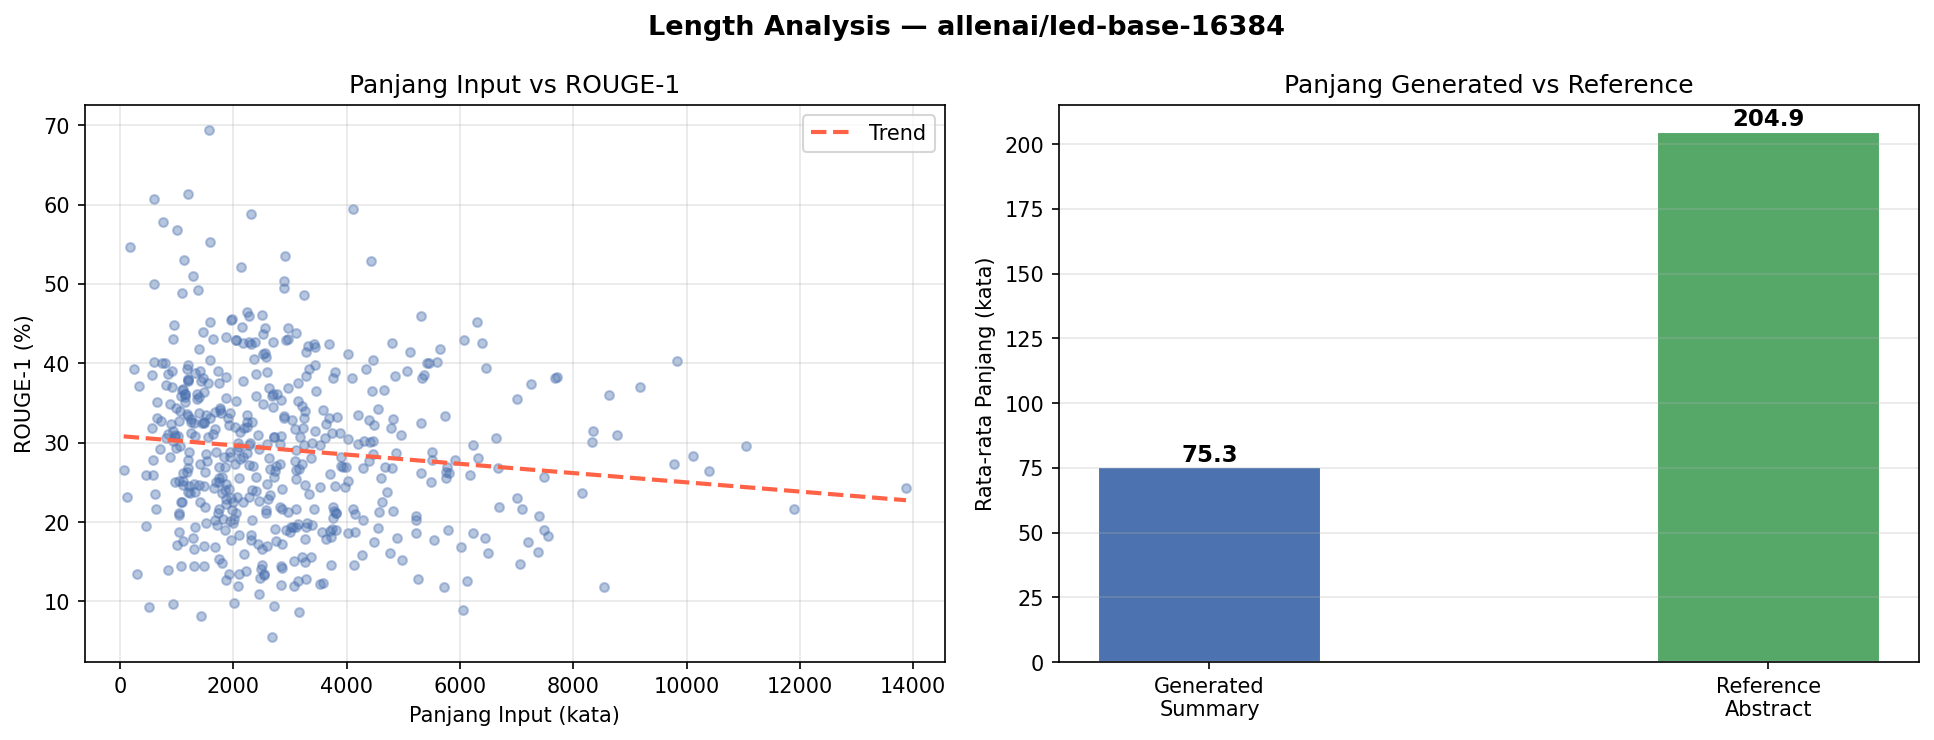


📊 Rouge Bar Hist


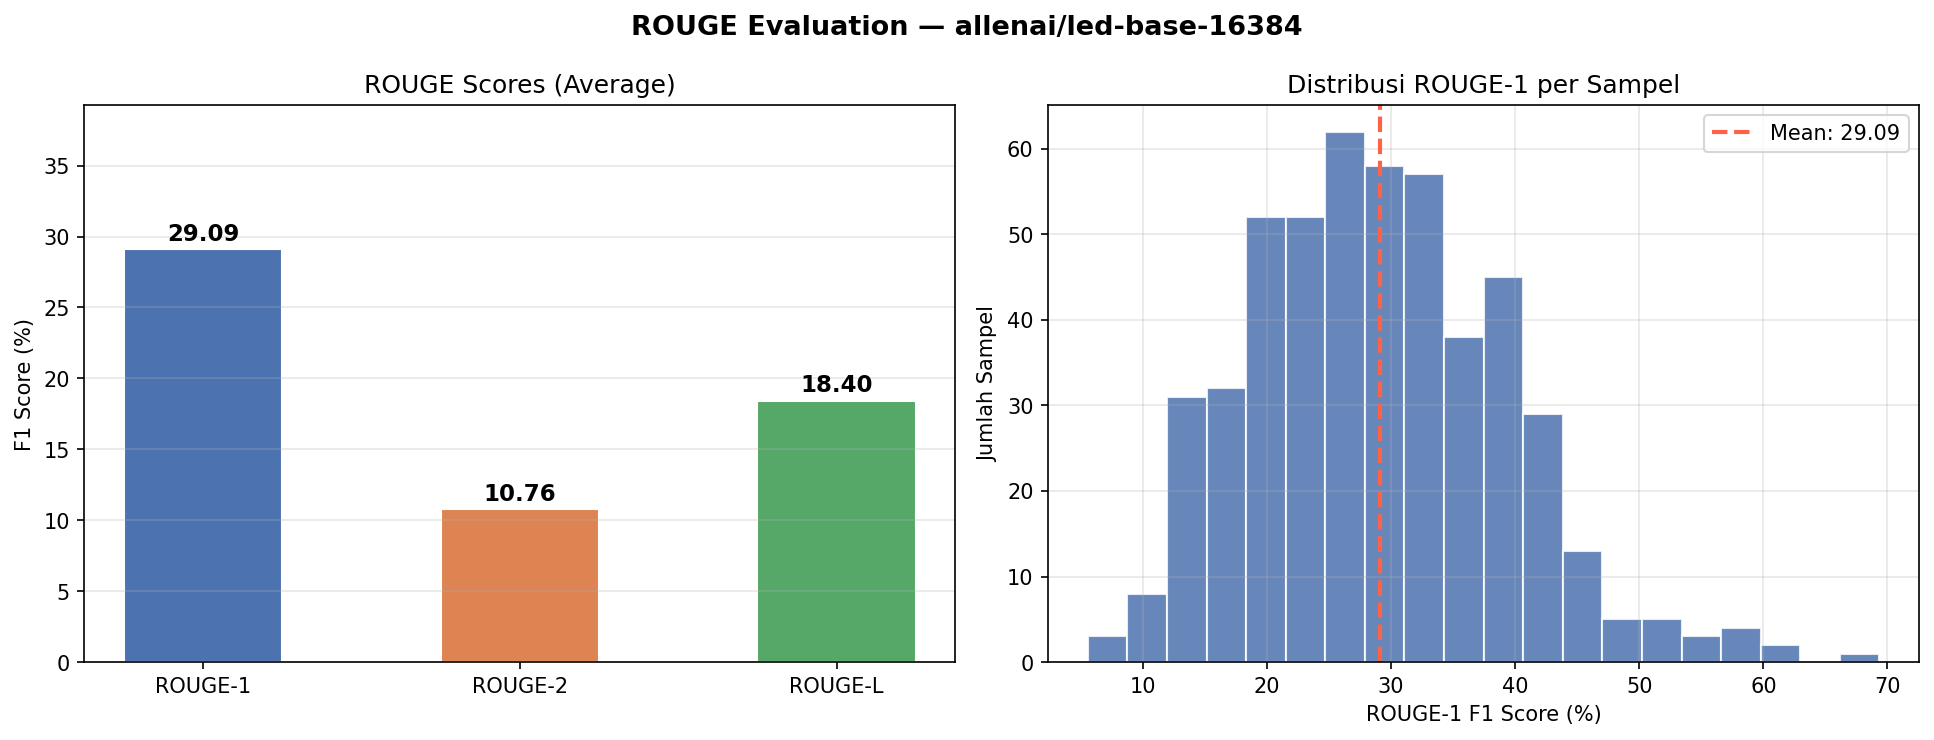


📊 Rouge Boxplot


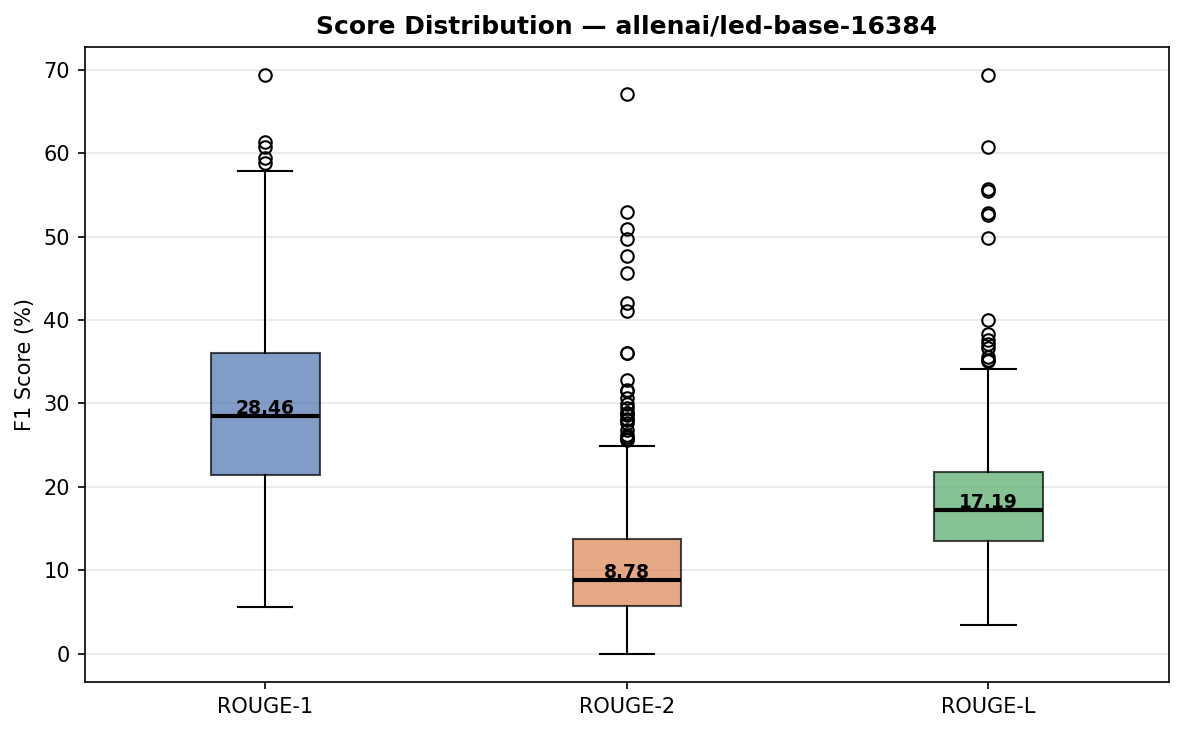


📊 Training Curves


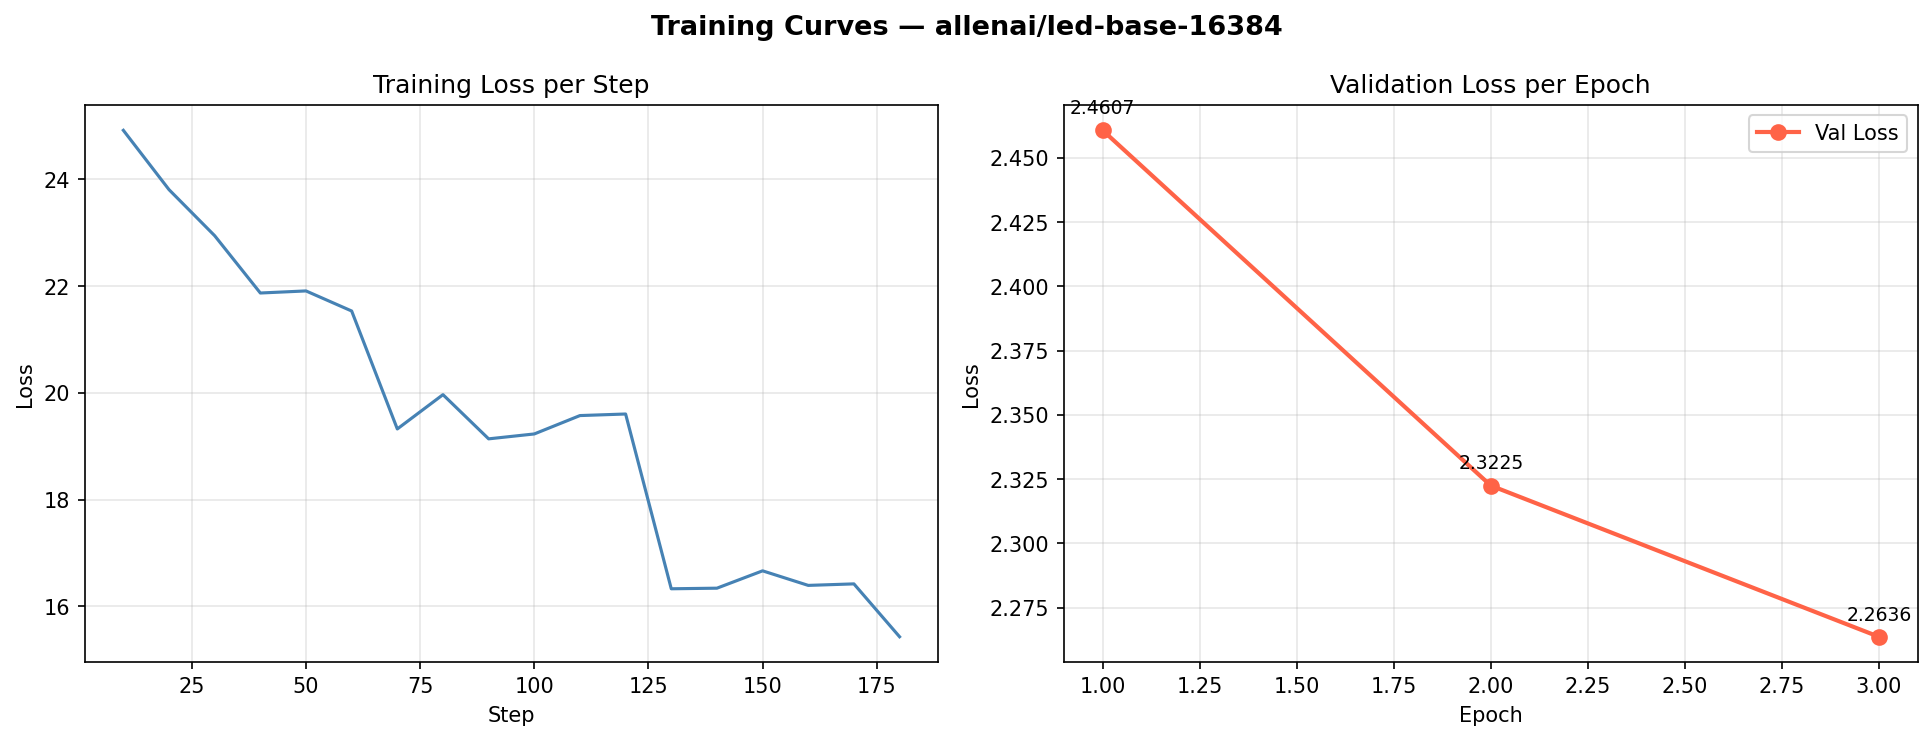

In [23]:
from IPython.display import display, Image
import glob

# ── Tampilkan semua visualisasi ──
viz_files = sorted(glob.glob('./viz_*.png'))
print(f"Total visualisasi: {len(viz_files)}")
print("=" * 50)

for f in viz_files:
    name = f.replace('./viz_', '').replace('.png', '').replace('_', ' ').title()
    print(f"\n📊 {name}")
    display(Image(filename=f, width=900))


In [25]:
import json

# Simpan predictions
output_data = {
    'model': 'LED',
    'model_name': MODEL_NAME,
    'dataset': 'PubMed (ccdv/pubmed-summarization)',
    'rouge_scores': rouge_scores,
    'num_test_samples': len(test_data),
    'max_input_length': MAX_INPUT_LENGTH,
    'max_target_length': MAX_TARGET_LENGTH,
    'predictions': generated_summaries,
    'references': reference_summaries
}

with open('led_predictions.json', 'w') as f:
    json.dump(output_data, f, indent=2)

print('✅ led_predictions.json saved!')
print('✅ led_rouge_results.csv saved!')

✅ led_predictions.json saved!
✅ led_rouge_results.csv saved!


---
## 💾 Simpan Hasil ke Google Drive

In [26]:
from google.colab import drive
import shutil, os, glob

# Mount Google Drive
drive.mount('/content/drive')

# ── Path tujuan di Drive ──
DRIVE_PATH = '/content/drive/My Drive/Binus/Semester_4/NLP/FinalProject/Result/LED'
os.makedirs(DRIVE_PATH, exist_ok=True)

# ── Simpan visualisasi ke Drive ──
viz_files = glob.glob('./viz_*.png')
for f in viz_files:
    shutil.copy(f, DRIVE_PATH)
    print(f'  ✅ {f} → Drive')

# ── Simpan hasil evaluasi ke Drive ──
shutil.copy('led_rouge_results.csv', DRIVE_PATH)
shutil.copy('led_predictions.json', DRIVE_PATH)
print(f'  ✅ led_rouge_results.csv → Drive')
print(f'  ✅ led_predictions.json → Drive')

print(f'\n✅ Semua hasil disimpan ke: {DRIVE_PATH}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  ✅ ./viz_rouge_boxplot.png → Drive
  ✅ ./viz_training_curves.png → Drive
  ✅ ./viz_length_analysis.png → Drive
  ✅ ./viz_rouge_bar_hist.png → Drive
  ✅ led_rouge_results.csv → Drive
  ✅ led_predictions.json → Drive

✅ Semua hasil disimpan ke: /content/drive/My Drive/Binus/Semester_4/NLP/FinalProject/Result/LED


---
## 6. Evaluasi Kualitatif

In [27]:
sc = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

print('=' * 60)
print('         EVALUASI KUALITATIF — LED')
print('=' * 60)

for idx in range(3):
    print(f'\n📄 SAMPEL #{idx+1}')
    print('-' * 60)
    print('[INPUT — 80 kata pertama]:')
    print(' '.join(test_data[idx]['input_text'].split()[:80]) + '...')
    print('\n[GENERATED SUMMARY (LED)]:')
    print(generated_summaries[idx])
    print('\n[REFERENCE ABSTRACT]:')
    print(reference_summaries[idx][:400] + '...')
    s = sc.score(reference_summaries[idx], generated_summaries[idx])
    print(f'\n[ROUGE per sampel]: R1={s["rouge1"].fmeasure*100:.1f} | R2={s["rouge2"].fmeasure*100:.1f} | RL={s["rougeL"].fmeasure*100:.1f}')
    print('-' * 60)


         EVALUASI KUALITATIF — LED

📄 SAMPEL #1
------------------------------------------------------------
[INPUT — 80 kata pertama]:
anxiety affects quality of life in those living with parkinson 's disease ( pd ) more so than overall cognitive status , motor deficits , apathy , and depression [ 13 ] . although anxiety and depression are often related and coexist in pd patients , recent research suggests that anxiety rather than depression is the most prominent and prevalent mood disorder in pd [ 5 , 6 ] . yet , our current understanding of anxiety and its impact...

[GENERATED SUMMARY (LED)]:
background: anxiety affects quality of life in those living with parkinson 's disease ( pd ) more so than overall cognitive status , motor deficits , apathy , and depression [ 13 ] . summary the cross - sectional data from these participants were taken from a patient database that has been compiled over the past 8 years ( since 2008 ) at the brain and mind centre , university of sydney . purpo

In [28]:
qualitative_checklist = {
    'Mencakup tujuan penelitian': '?',
    'Mencakup metode': '?',
    'Mencakup hasil utama': '?',
    'Mencakup kesimpulan': '?',
    'Koheren dan mudah dipahami': '?',
    'Ada indikasi hallucination': '?',
    'Kehilangan konteks penting': '?',
}

print('\n📋 Checklist Evaluasi Kualitatif LED:')
print('-' * 50)
for k, v in qualitative_checklist.items():
    print(f'  {k:45s}: {v}')
print('\n⚠️  Isi checklist di atas setelah membaca hasil sampel.')



📋 Checklist Evaluasi Kualitatif LED:
--------------------------------------------------
  Mencakup tujuan penelitian                   : ?
  Mencakup metode                              : ?
  Mencakup hasil utama                         : ?
  Mencakup kesimpulan                          : ?
  Koheren dan mudah dipahami                   : ?
  Ada indikasi hallucination                   : ?
  Kehilangan konteks penting                   : ?

⚠️  Isi checklist di atas setelah membaca hasil sampel.


---
## 7. Simpan Hasil & Zip Output

In [29]:
import json, shutil, os

output_data = {
    'model': 'LED',
    'model_name': MODEL_NAME,
    'dataset': 'PubMed (ccdv/pubmed-summarization)',
    'rouge_scores': rouge_scores,
    'num_test_samples': len(test_data),
    'max_input_length': MAX_INPUT_LENGTH,
    'max_target_length': MAX_TARGET_LENGTH,
    'predictions': generated_summaries,
    'references': reference_summaries
}

with open('led_predictions.json', 'w') as f:
    json.dump(output_data, f, indent=2)

# Zip semua output LED
os.makedirs('/content/led_output', exist_ok=True)
shutil.copytree('./led-pubmed-finetuned', '/content/led_output/led-pubmed-finetuned')
shutil.copy('led_rouge_results.csv', '/content/led_output/')
shutil.copy('led_predictions.json', '/content/led_output/')

shutil.make_archive('/content/led_output', 'zip', '/content', 'led_output')

print('✅ Pipeline LED selesai!')
print(f'  ROUGE-1 : {rouge_scores["ROUGE-1"]}')
print(f'  ROUGE-2 : {rouge_scores["ROUGE-2"]}')
print(f'  ROUGE-L   : {rouge_scores["ROUGE-L"]}')
print('\nFile: /content/led_output.zip')
print('→ Semua model selesai! Lanjut ke Comparative Analysis.')


✅ Pipeline LED selesai!
  ROUGE-1 : 29.09
  ROUGE-2 : 10.76
  ROUGE-L   : 18.4

File: /content/led_output.zip
→ Semua model selesai! Lanjut ke Comparative Analysis.


In [32]:
from google.colab import drive
import shutil, os

# Mount Google Drive
drive.mount('/content/drive')

# Path tujuan di Drive — sesuaikan nama foldernya
DRIVE_PATH = '/content/drive/My Drive/Binus/Semester_4/NLP/FinalProject/Result/LED'
os.makedirs(DRIVE_PATH, exist_ok=True)

# Copy semua hasil ke Drive
shutil.copy('led_rouge_results.csv', DRIVE_PATH)
shutil.copy('led_predictions.json', DRIVE_PATH)

# Kalau mau simpan model weights juga (opsional, ukuran besar)
# shutil.copytree('./bart-pubmed-finetuned', f'{DRIVE_PATH}/bart-pubmed-finetuned')

print(f'✅ Hasil disimpan ke Drive: {DRIVE_PATH}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Hasil disimpan ke Drive: /content/drive/My Drive/Binus/Semester_4/NLP/FinalProject/Result/LED


In [33]:
from google.colab import drive
import shutil, os

drive.mount('/content/drive')

# Path di Drive
DRIVE_MODEL_PATH = '/content/drive/My Drive/Binus/Semester_4/NLP/FinalProject/Models/LED'
os.makedirs(DRIVE_MODEL_PATH, exist_ok=True)

# Copy model weights ke Drive
print('Menyimpan model ke Drive...')
shutil.copytree('./led-pubmed-finetuned', f'{DRIVE_MODEL_PATH}/led-pubmed-finetuned')
print(f'✅ Model disimpan ke: {DRIVE_MODEL_PATH}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Menyimpan model ke Drive...
✅ Model disimpan ke: /content/drive/My Drive/Binus/Semester_4/NLP/FinalProject/Models/LED
